In [16]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("NumPy :", np.__version__)
print("TensorFlow :", tf.__version__)
print("Matplotlib :", plt.matplotlib.__version__)

NumPy : 2.1.3
TensorFlow : 2.20.0
Matplotlib : 3.10.0


In [17]:
x_input = tf.constant([
    [20,20], [20,25], [20,30],
    [30,20], [30,25], [30,30],
    [40,20], [40,25], [40,30],
    [50,20], [50,25], [50,30],
    [60,20], [60,25], [60,30],
    [70,20], [70,25], [70,30]
], dtype=tf.float32)

labels = tf.constant([
    [0], [0], [0],
    [0], [0], [1],
    [0], [1], [1],
    [0], [1], [1],
    [1], [1], [1],
    [1], [1], [1]
], dtype=tf.float32)


min max scaler

In [18]:
x_input_org = x_input
x_min,x_max = np.min(x_input,axis = 0) ,np.max(x_input,axis = 0)
x_input = (x_input - x_min)/(x_max - x_min)

model정의

In [19]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape =(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

model compile

In [20]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate= 0.01), loss='binary_crossentropy',metrics=['accuracy'])

학습

In [21]:
%%time
history = model.fit(x_input,labels,epochs = 1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step - accuracy: 0.3889 - loss: 0.7772
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3333 - loss: 0.7762
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3333 - loss: 0.7751
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3333 - loss: 0.7741
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3333 - loss: 0.7730
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3333 - loss: 0.7720
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3333 - loss: 0.7710
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3333 - loss: 0.7700
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3889 - loss: 0.7690
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3889 - loss: 0.7680
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3889 - loss: 0.7670
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy

plot

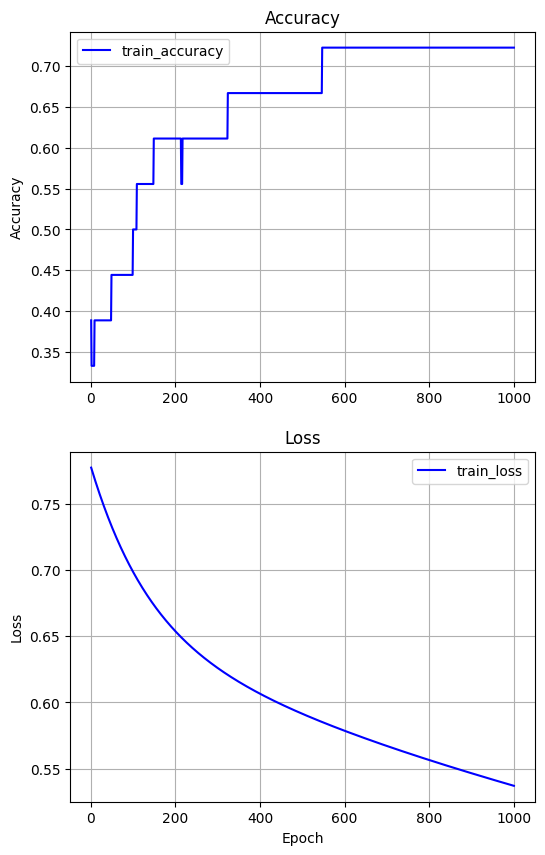

In [22]:
loss = history.history['loss']
epochs = range(1, len(loss)+1)
plt.figure(figsize=(6, 10))
plt.subplot(2, 1, 1)
plt.title('Accuracy')
plt.plot(epochs, history.history['accuracy'], 'b', label='train_accuracy')
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(epochs, history.history['loss'], 'b', label='train_loss')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

traning결과 test

In [23]:
def predict(x):
  return model.predict((x - x_min)/(x_max - x_min))

In [24]:
x_test = tf.constant([[30.0,15.0]], dtype = tf.float32)
H_x = predict(x_test)
print("Age : {}, BMI : {} => Result : {:>7.4}".format(x_test[0,0],x_test[0,1],H_x[0,0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Age : 30.0, BMI : 15.0 => Result :  0.5926
